In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.13.0'

In [4]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [5]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [10]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [11]:
def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None):
    plt.figure(figsize=(10, 7))

    plt.scatter(train_data, train_labels, c='b', s=4, label="Training data")

    plt.scatter(test_data, test_labels, c='g', s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label='Predictions')

    plt.legend(prop={"size":14})

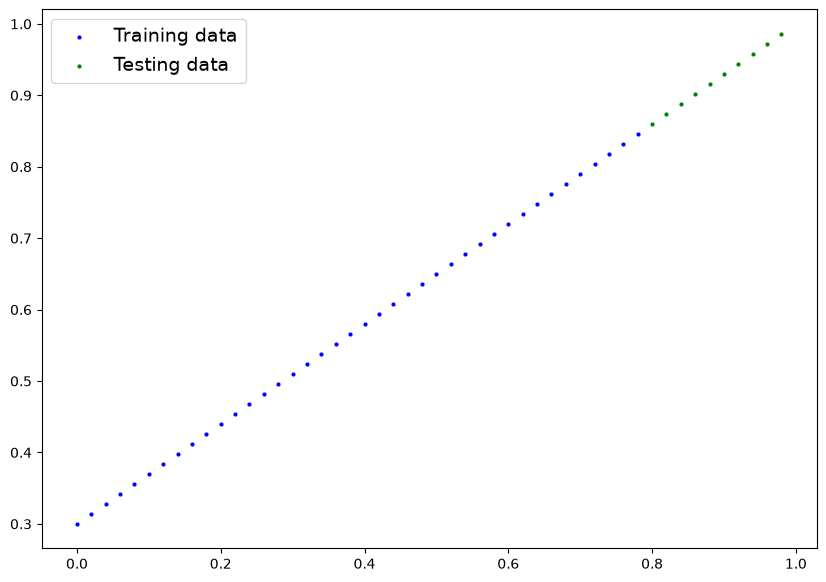

In [12]:
plot_predictions(X_train, y_train, X_test, y_test)

In [13]:
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [14]:
next(model_1.parameters()).device

device(type='cpu')

In [15]:
model_1.to(device)
next(model_1.parameters()).device

device(type='mps', index=0)

In [16]:
# Create loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), # optimize newly created model's parameters
                            lr=0.01)

In [18]:
torch.manual_seed(42)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

epochs = 1000

for epoch in range(epochs):
    model_1.train()

    y_pred = model_1(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_1.eval()

    with torch.inference_mode():
        test_pred = model_1(X_test)

        test_loss = loss_fn(test_pred, y_test)

        if epoch % 100 == 0:
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss}")

Epoch: 0 | MAE Train Loss: 0.5436569452285767 | MAE Test Loss: 0.560505211353302
Epoch: 100 | MAE Train Loss: 0.005878164432942867 | MAE Test Loss: 0.012984687462449074
Epoch: 200 | MAE Train Loss: 0.010256480425596237 | MAE Test Loss: 0.0003308236482553184
Epoch: 300 | MAE Train Loss: 0.010256480425596237 | MAE Test Loss: 0.0003308236482553184
Epoch: 400 | MAE Train Loss: 0.010256480425596237 | MAE Test Loss: 0.0003308236482553184
Epoch: 500 | MAE Train Loss: 0.010256480425596237 | MAE Test Loss: 0.0003308236482553184
Epoch: 600 | MAE Train Loss: 0.010256480425596237 | MAE Test Loss: 0.0003308236482553184
Epoch: 700 | MAE Train Loss: 0.010256480425596237 | MAE Test Loss: 0.0003308236482553184
Epoch: 800 | MAE Train Loss: 0.010256480425596237 | MAE Test Loss: 0.0003308236482553184
Epoch: 900 | MAE Train Loss: 0.010256480425596237 | MAE Test Loss: 0.0003308236482553184


In [19]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6929]], device='mps:0')),
             ('linear_layer.bias', tensor([0.2925], device='mps:0'))])

In [20]:
model_1.eval()

with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8468],
        [0.8607],
        [0.8746],
        [0.8884],
        [0.9023],
        [0.9161],
        [0.9300],
        [0.9438],
        [0.9577],
        [0.9716]], device='mps:0')

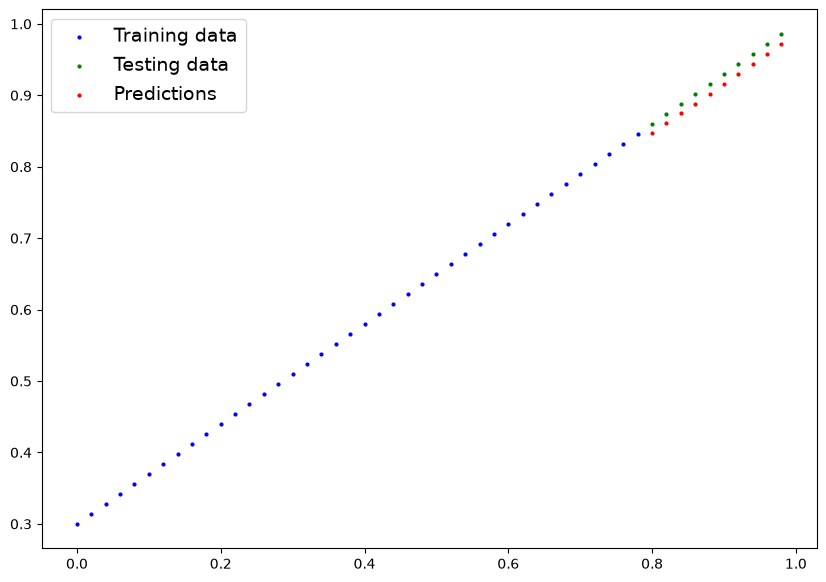

In [22]:
plot_predictions(predictions=y_preds.cpu())